# YZ50 — Week 2: Backpropagation

- Backpropagation is a method used in artificial neural networks to calculate the gradients of the loss function by propagating them backward—using the chain rule—from the network's output back to the input.

- A gradient vector is a vector containing the partial derivatives (gradient values) of a multivariable function with respect to each variable; it indicates the direction and rate at which the function increases.

## Gradient and Its Role in Gradient Descent

- A **gradient** indicates the direction in which a function increases most rapidly and how strongly it changes in that direction.

In neural networks, the gradient of the loss function with respect to the model parameters shows how each weight and bias affects the loss.

Gradient descent uses the gradient to update the model parameters in the opposite direction, with the goal of reducing the loss.

The parameter update rule is:

θ_new = θ_old - η ∇L(θ)

Where:

- **θ** represents the model parameters (weights and biases).
- **∇L(θ)** is the gradient of the loss function with respect to the parameters.
- **η** is the learning rate.

In short, **the gradient tells gradient descent in which direction and by how much the parameters should be changed to reduce the loss.**

# Building a Micrograd (Autograd Engine)

# 1. Kendi Value sınıfını yaz, toplama ve çarpma ile başla. Her yeni Value, kendisini üreten Value'ları ve hangi işlemden çıktığını saklasın

- Value class

In [255]:
import math
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # bu node'un gradyanı (derivative of the function with respect to this node).
        self._backward = lambda: None # bu node'un gradyanını hesaplamak için kullanılacak fonksiyon.
        self._prev = set(_children) # bu node'u oluştururken kullanılan önceki Value objelerini saklar.
        self._op = _op # hangi işlemle bu node'un oluşturulduğunu saklar.
        self.label = label

    def __repr__(self):
        return f"Value(Data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # wrap other in Value if it's not already a Value like an int or float
        out = Value(self.data + other.data, _children=(self, other), _op='+')

        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0

        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, _children=(self, other), _op='*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    
    # Reverse operations: these are called when the left operand does not support the operation with the right operand
    def __rmul__(self, other): # called when the left operand does not support the multiplication operation with the right operand
        return self * other

    def __radd__(self, other): # called when the left operand does not support the addition operation with the right operand
        return self + other

    def __rpow__(self, other): # called when the left operand does not support the power operation with the right operand
        return self ** other

    def __rsub__(self, other): # called when the left operand does not support the subtraction operation with the right operand 
        return other + (-self)
    

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, _children=(self,), _op=f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
            
        out._backward = _backward
        return out

    def __truediv__(self, other): # called when the left operand does not support the division operation with the right operand
        return self * other**-1

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, _children=(self,), _op='tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
            
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), _children=(self,), _op='exp')

        def _backward():
            self.grad += out.data * out.grad
            
        out._backward = _backward
        return out

    def backward(self):
        # Topological sort
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
# a + b   = a.__add__(b)
# a * b   = a.__mul__(b)
e = a * b; e.label = 'e'
# d = a*b + c # = (a.__mul__(b)).__add__(c) # '+'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(Data=-8.0)

In [256]:
print(a+1) # Value(3.0)
print(a*2) # Value(4.0)

# after __rmul__ is implemented, the following will also work:
print(2*a) # Value(4.0)

print(a/b)

print(a-b) # Value(5.0)

print(-a) # Value(-2.0)

Value(Data=3.0)
Value(Data=4.0)
Value(Data=4.0)
Value(Data=-0.6666666666666666)
Value(Data=5.0)
Value(Data=-2.0)


In [257]:
d._prev

{Value(Data=-6.0), Value(Data=10.0)}

In [258]:
d._op

'+'

##  Graph Virtualization

In [259]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

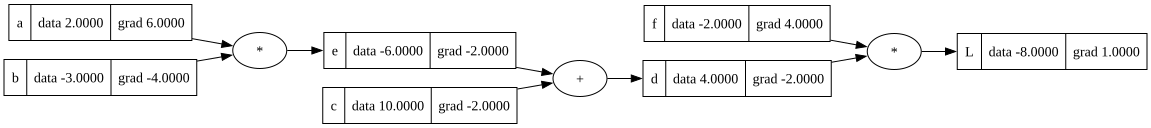

In [286]:
draw_dot(L)

In [261]:
L.grad = 1.0
f.grad = 4.0
d.grad = -2.0
c.grad = -2.0
e.grad = -2.0
b.grad = -4.0
a.grad = 6.0

- We are able to build mathematical expressions using addition (+) and multiplication (*). So far, these expressions are scalar-valued along the way, and we can perform a forward pass to build a **mathematical expression**. We have multiple inputs here, **(a, b, c, and f)**, going into a mathematical expression that produces a single output, **L**. The output of L is -8.

- What we want to do next is **backpropagation**. In backpropagation, we start from the end and work backward, calculating the gradient with respect to all of the intermediate values. Specifically, we compute the **derivative of the function L with respect to each node**.

- In a neural network setting, we would be taking the derivative of the **Loss Function L** with respect to a **weight of the neural network**. The inputs, such as **a, b, c, and f**, are not weights because they are input values. Since the inputs are fixed, we generally do not need to compute the derivative of the loss with respect to the inputs when updating the network's parameters.

## Mathematical derivative formulas & chain rule

L = d * f
dL/dd = ?

(f(x+h)-f(x))/h

(((d+h)*f)-(d*f))/h

((df+hf)-df)/h

(hf)/h

f

------------------------------------------------

- Chain rule

dL/dc = ?  == (dL/dd) * (dd/dc) = dL/dc

we know dL/dd = f
so find dd/dc

dd/dc = ?

d = e + c

(f(x+h)-f(x))/h

(((c+h)+e)-(c+e))/h

(c+h+e-c-e)/h

h/h

1.0

### So 
dL/dd * dd/dc = dL/dc

f * 1 = f

- also dL/de = f * 1 = f = -2

------------------------------------------------

dL/da = ? ; dL/db = ? 

e = a * b

de/da = b

de/db = a

we know dL/de = f = -2 

dL/de * de/da = dL/da

-2 * b = -2b = 6 

dL/de * de/db = dL/db

-2 * a = -2a = -4

# 2. Otomatikleştirmeden önce gradient'leri videodaki iki örnekte elle doldur

- {f(x+h)-f(x)} / h

In [262]:
def lol():

    h = 0.001

    '''Derivative of the function with respect to L.'''
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L2 = L.data + h

    dl_dL = (L2 - L1) / h

    print(f'dL/dL = {dl_dL:.4f}')



    '''Derivative of the function with respect to d.'''
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    d.data += h # increase d
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    dl_dd = (L2 - L1) / h

    print(f'dL/dd = {dl_dd:.4f}')   



    '''Derivative of the function with respect to f.'''
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    f.data += h # increase f
    L = d * f; L.label = 'L'
    L2 = L.data

    dl_df = (L2 - L1) / h

    print(f'dL/df = {dl_df:.4f}') 


    '''Derivative of the function with respect to c.'''
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    c.data += h # increase c
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    dl_dc = (L2 - L1) / h

    print(f'dL/dc = {dl_dc:.4f}') 

    '''Derivative of the function with respect to e.'''
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    e.data += h # increase e
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    dl_de = (L2 - L1) / h

    print(f'dL/de = {dl_de:.4f}') 

    '''Derivative of the function with respect to b.'''
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    b.data += h # increase b
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    dl_db = (L2 - L1) / h

    print(f'dL/db = {dl_db:.4f}')

    '''Derivative of the function with respect to a.'''
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    a.data += h # increase a
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    dl_da = (L2 - L1) / h

    print(f'dL/da = {dl_da:.4f}') 

lol()

dL/dL = 1.0000
dL/dd = -2.0000
dL/df = 4.0000
dL/dc = -2.0000
dL/de = -2.0000
dL/db = -4.0000
dL/da = 6.0000


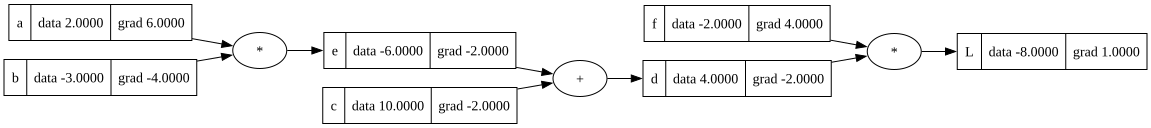

In [263]:
draw_dot(L)

# Geri Yayılım (Backpropagation) Gradyan Akış Kuralları Çıkarımları

## 1. Toplama Kapısı (+) : "Dağıtıcı" (Distributor)
* **Kural:** Toplama işlemi, kendisine gelen gradyanı değiştirmeden tüm girişlerine **aynen dağıtır** (kopyalar).
* **Matematiksel Karşılığı:** $f(x,y) = x + y$ için türevler $1$ olduğu için gelen gradyan $1$ ile çarpılır.

## 2. Çarpma Kapısı (*) : "Çaprazlayıcı" (Switcher)
* **Kural:** Çarpma işlemi, kendisine gelen gradyanı diğer girişin **değeriyle çarparak** (çaprazlayarak) iletir. Bir dalın gradyanını, diğer dalın *ileriye dönük (forward) değeri* belirler.
* **Matematiksel Karşılığı:** $f(x,y) = x * y$ işleminde zincir kuralı (chain rule) gereği türevler yer değiştirir. $x$'in gradyanı hesaplanırken gelen gradyan (e den gelen gradyan [-2]) $y$'nin değeriyle [2] çarpılır.

## Tek bi Nöronda Backpropagation

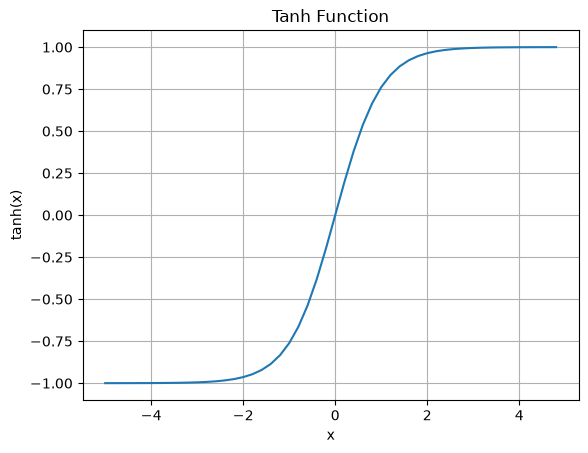

In [264]:
import numpy as np
import matplotlib.pyplot as plt

# tanh function plot
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.title('Tanh Function')
plt.grid(True)
plt.show()

In [265]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.88137358, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

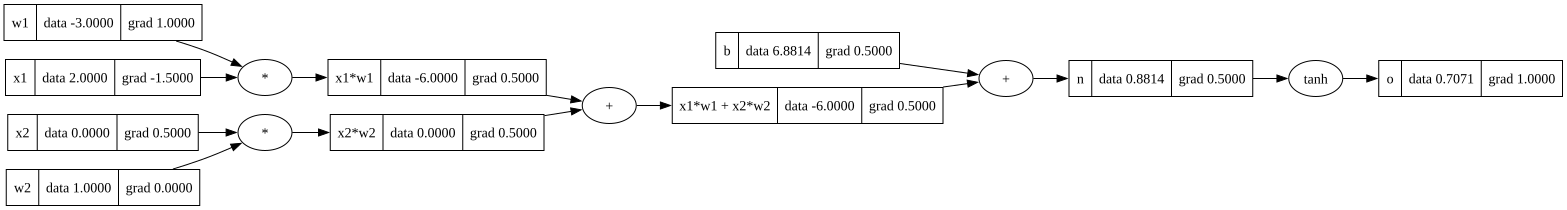

In [266]:
draw_dot(o)

In [267]:
o.backward()

In [268]:
# Manually setting the gradients for backpropagation

o.grad = 1.0
n.grad = 0.5
x1w1x2w2.grad = 0.5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [269]:
# o = tanh(n)

# do/dn = 1 - tanh(n)**2             ==          1 - o**2

1 - o.data**2

0.5000000049635664

In [270]:
# outomatic backpropagation

o.grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
b._backward()
x1w1._backward()
x2w2._backward()
x2._backward()
w2._backward()
x1._backward()
w1._backward()


# 3. backward() metodunu yaz: çıktının gradient'ini 1 yap, node'ları ters topological sırayla gez, her node'da chain rule uygula. Bir değişken birden fazla yerde kullanılıyorsa gradient'leri topla, üzerine yazma



- Topological Sort (Topological Ordering): Yönlü döngüsüz bir grafın (DAG) tüm düğümlerinin, her u→v kenarı için u'nun v'den önce geldiği doğrusal bir sıraya dizilmesidir.

- backpropagation yapabilmemiz için bu topological sortun reversini almamız gerekir

In [271]:
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)
topo

for node in reversed(topo):
    node._backward()

# bu fonksiyonu backward() olarak Value sınıfına ekliyoruz.

### Bir değişken birden fazla işlemde kullanıldığı zaman

**self.grad = out.grad * 1.0** işleminde ardısıra aynı değişkene gelen işlemler yüzünden gradienti üstüne yazma olur.

- Çözüm 

**self.grad += out.grad * 1.0**   gradient böyle senaryolar için += ile toplamak

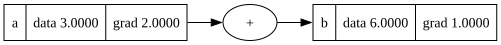

In [272]:
a = Value(3.0, label='a')
b = a + a   ; b.label = 'b'
b.backward()
draw_dot(b)

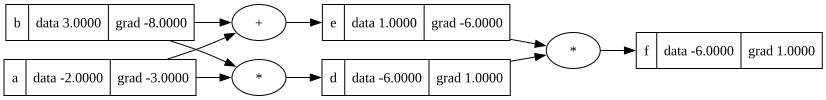

In [273]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b      ; d.label = 'd'
e = a + b      ; e.label = 'e'
f = d * e      ; f.label = 'f'

f.backward()

draw_dot(f)

# 4. tanh'ı parçala: exp, bölme ve pow operasyonlarını ekle, aynı gradient'leri aldığını göster. Sonra doğrula: aynı ifadeyi aynı değerlerle hem backwar() ile hem geçen haftaki numerical derivative ile hem de PyTorch ile hesapla, üçünün eşleştiğini göster.

## 4.1 Backward() Calculation

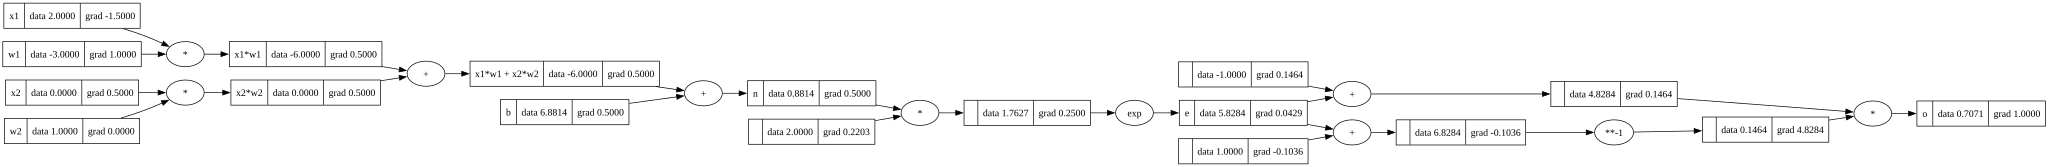

In [274]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.88137358, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#----------------------------------
e = (2*n).exp(); e.label = 'e'
o = (e-1)/(e+1); o.label = 'o'
#----------------------------------
o.backward()
draw_dot(o)

## 4.2 PyTorch Calculation

- in PyTorch everything around based on tensors, 
tensors are n dimentional arrays of scalers

In [275]:
import torch

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True # by default, pytorch assumes they do not require gradients, so we need to set requires_grad = True for the inputs and weights that we want to compute gradients for.
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


## 4.3 Numerical Derivative Calculation

In [276]:
## 4.3 Numerical Derivative Calculation

# Numerical derivative

h = 0.0001


def forward(x1, x2, w1, w2, b):
    """Expression'ın output değerini hesaplar."""
    
    x1w1 = x1 * w1
    x2w2 = x2 * w2
    
    n = x1w1 + x2w2 + b
    
    e = 2.718281828459045 ** (2 * n)
    o = (e - 1) / (e + 1)
    
    return o


# Initial values

x1 = 2.0
x2 = 0.0

w1 = -3.0
w2 = 1.0

b = 6.88137358

# Formula of derivative of the function with respect to x1, x2, w1, w2, b
# f(x+h) - f(x) / h

# Calculate the current output

o = forward(x1, x2, w1, w2, b)

print(f"Output: {o:.6f}")


# Calculate numerical derivatives

x1_gradient = (
    forward(x1 + h, x2, w1, w2, b) - o
) / h

x2_gradient = (
    forward(x1, x2 + h, w1, w2, b) - o
) / h

w1_gradient = (
    forward(x1, x2, w1 + h, w2, b) - o
) / h

w2_gradient = (
    forward(x1, x2, w1, w2 + h, b) - o
) / h

b_gradient = (
    forward(x1, x2, w1, w2, b + h) - o
) / h


# Display the gradients

print(f"x1 gradient: {x1_gradient:.6f}")
print(f"x2 gradient: {x2_gradient:.6f}")
print(f"w1 gradient: {w1_gradient:.6f}")
print(f"w2 gradient: {w2_gradient:.6f}")
print(f"b gradient:  {b_gradient:.6f}")

Output: 0.707107
x1 gradient: -1.500318
x2 gradient: 0.499965
w1 gradient: 0.999859
w2 gradient: 0.000000
b gradient:  0.499965


# 5. Videodaki sırayı izleyerek Neuron, Layer ve MLP sınıflarını kur. Parametreleri tek listede topla, videodaki küçük veri setiyle eğit, loss'un adım adım düştüğünü göster.

In [277]:
import random

class Neuron:
    
    def __init__(self, nin): # nin: number of inputs
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)] # random weights for each input
        self.b = Value(random.uniform(-1, 1)) # random bias

    def __call__(self, x): # called when neuron n is called like a function, e.g. n(x)
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) # sum of w*x + b
        out = act.tanh() # activation function
        return out

    def parameters(self): # return the parameters of the neuron (weights and bias)
        return self.w + [self.b] # return list of weights and bias

class Layer: # layer is a just list of neurons, each neuron has its own weights and bias
    
    def __init__(self, nin, nout): # nin: number of inputs, nout: number of outputs (how many neurons in this layer)
        self.neurons = [Neuron(nin) for _ in range(nout)] # create nout neurons, each with nin inputs

    def __call__(self, x):
        outs = [n(x) for n in self.neurons] # call each neuron with input x
        return outs[0] if len(outs) == 1 else outs # if only one output, return it, else return list of outputs

    def parameters(self): # return the parameters of the layer (weights and bias of each neuron)
        return [p for neuron in self.neurons for p in neuron.parameters()] # return list of parameters of each neuron

class MLP: # multi-layer perceptron, a neural network with multiple layers
    
    def __init__(self, nin, nouts): # nin: number of inputs, nouts: list of number of outputs for each layer
        sz = [nin] + nouts # size of each layer
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] # create layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x) # pass input through each layer
        return x

    def parameters(self): # return the parameters of the network (weights and bias of each layer)
        return [p for layer in self.layers for p in layer.parameters()] # return list of parameters of each layer


x = [2.0, 3.0, -1.0] # input to the network
n = MLP(3, [4, 4, 1]) # create a network with 3 inputs, 2 hidden layers with 4 neurons each, and 1 output
out = n(x) # forward pass through the network

print(out) # output of the network

Value(Data=0.13612926628276678)


In [278]:
n.parameters() # parameters of the network (weights and bias of each layer)

[Value(Data=0.15255193979434423),
 Value(Data=-0.8487321838796476),
 Value(Data=0.9232609458537329),
 Value(Data=-0.07722450172260253),
 Value(Data=0.9747357829500063),
 Value(Data=0.8192160618371962),
 Value(Data=-0.8785825802064944),
 Value(Data=0.4216167243193547),
 Value(Data=-0.6717509466905061),
 Value(Data=0.01764100157494708),
 Value(Data=0.7691132818909545),
 Value(Data=0.6363723721384684),
 Value(Data=0.6114584973521009),
 Value(Data=0.5760057715695004),
 Value(Data=-0.5877352120472417),
 Value(Data=-0.8514375230473676),
 Value(Data=0.23826481504413644),
 Value(Data=0.1657464290716899),
 Value(Data=-0.2839909247862551),
 Value(Data=-0.6954122119692221),
 Value(Data=-0.6630128465097322),
 Value(Data=0.6841865914687055),
 Value(Data=0.9325201677543704),
 Value(Data=0.9939282163775707),
 Value(Data=-0.8157982407579776),
 Value(Data=0.43603213283625775),
 Value(Data=0.6451798102648207),
 Value(Data=0.4588542732141687),
 Value(Data=0.9235154642275754),
 Value(Data=0.14318925934461

In [279]:
print(f"Number of parameters in the network: {len(n.parameters())}") # number of parameters in the network

Number of parameters in the network: 41


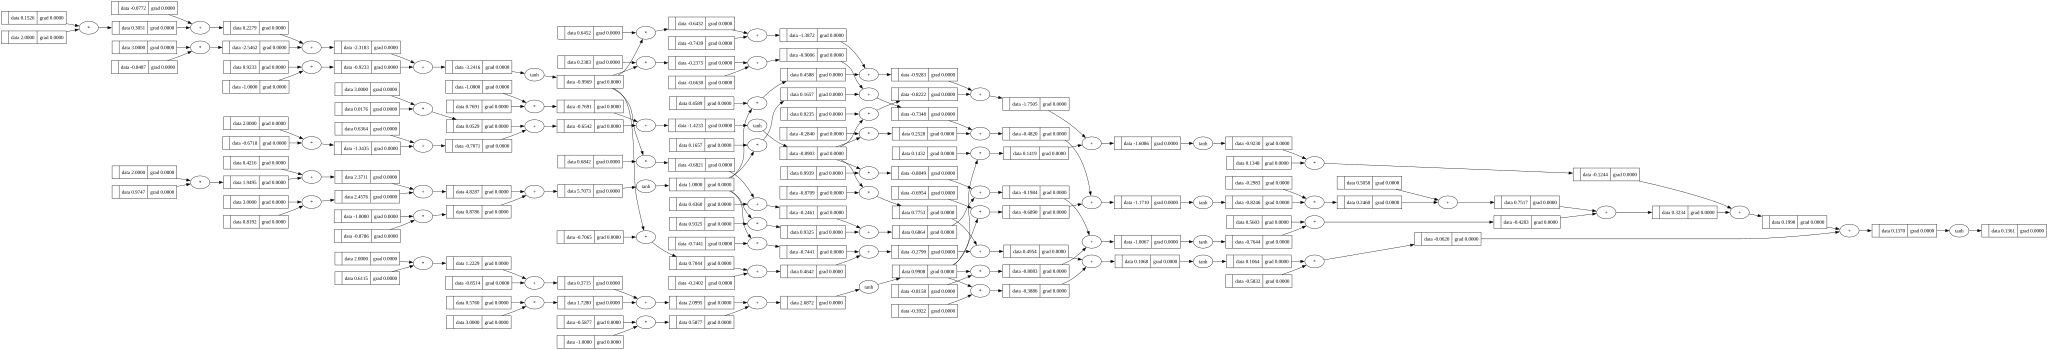

In [280]:
draw_dot(out) # visualize the computation graph of the output

## 5.1 Dataset

In [281]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

ys_pred = [n(x) for x in xs] # predicted outputs

ys_pred # print predicted outputs

[Value(Data=0.13612926628276678),
 Value(Data=0.8842393472282313),
 Value(Data=0.9366619736457631),
 Value(Data=0.35442013739246725)]

In [282]:
# SSE
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ys_pred)) # calculate the loss for each output
loss

Value(Data=8.464063521386086)

In [283]:
loss.backward() # compute gradients for all parameters in the network

### The Neural Network Training

Epoch 1/100, Loss: 8.4641
Epoch 2/100, Loss: 8.1022
Epoch 3/100, Loss: 7.8764
Epoch 4/100, Loss: 7.7190
Epoch 5/100, Loss: 7.5954
Epoch 6/100, Loss: 7.4873
Epoch 7/100, Loss: 7.3839
Epoch 8/100, Loss: 7.2778
Epoch 9/100, Loss: 7.1627
Epoch 10/100, Loss: 7.0325
Epoch 11/100, Loss: 6.8807
Epoch 12/100, Loss: 6.6996
Epoch 13/100, Loss: 6.4801
Epoch 14/100, Loss: 6.2124
Epoch 15/100, Loss: 5.8866
Epoch 16/100, Loss: 5.4957
Epoch 17/100, Loss: 5.0394
Epoch 18/100, Loss: 4.5279
Epoch 19/100, Loss: 3.9837
Epoch 20/100, Loss: 3.4368
Epoch 21/100, Loss: 2.9175
Epoch 22/100, Loss: 2.4497
Epoch 23/100, Loss: 2.0479
Epoch 24/100, Loss: 1.7161
Epoch 25/100, Loss: 1.4495
Epoch 26/100, Loss: 1.2381
Epoch 27/100, Loss: 1.0707
Epoch 28/100, Loss: 0.9370
Epoch 29/100, Loss: 0.8288
Epoch 30/100, Loss: 0.7401
Epoch 31/100, Loss: 0.6663
Epoch 32/100, Loss: 0.6041
Epoch 33/100, Loss: 0.5511
Epoch 34/100, Loss: 0.5055
Epoch 35/100, Loss: 0.4660
Epoch 36/100, Loss: 0.4314
Epoch 37/100, Loss: 0.4009
Epoch 38/1

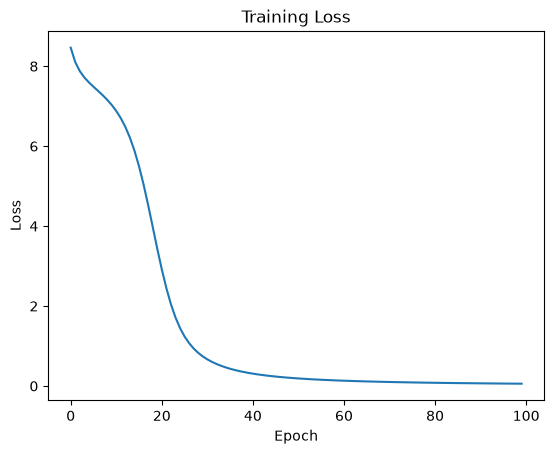

In [284]:
import matplotlib.pyplot as plt
epochs = 100

losses = []

for epoch in range(epochs):
    # forward pass
    ys_pred = [n(x) for x in xs] # predicted outputs
    # calculate the loss for each output
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ys_pred))
    losses.append(loss.data)

    # backward pass
    for p in n.parameters(): # ! if you don't reset the gradients to zero, the gradients will accumulate over epochs, which is not what we want. We want to compute the gradients for each epoch separately.
        p.grad = 0.0 # reset gradients to zero before backward pass
    # Backpropagation
    loss.backward() # compute gradients for all parameters in the network

    # Gradient descent / Formula: w = w - learning_rate * dw
    # update parameters using gradient descent
    learning_rate = 0.01
    for p in n.parameters():
        p.data -= learning_rate * p.grad # update parameter using gradient descent

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.data:.4f}")

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [285]:
ys_pred

[Value(Data=0.9201140787187495),
 Value(Data=-0.876570626034845),
 Value(Data=-0.8705608131489823),
 Value(Data=0.8617460207025335)]